In [1]:
"""NYC Taxi Trip Duration Prediction with Enhanced Features and Hyperparameter Tuning"""

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_squared_log_error)
import optuna
from optuna.integration import XGBoostPruningCallback

# Loading the Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
# Loading the Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Convert pickup_datetime to datetime
for df in [train, test]:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Drop dropoff_datetime from train
train.drop(['dropoff_datetime'], axis=1, inplace=True)

# Extract date and time features
for df in [train, test]:
    df['month'] = df['pickup_datetime'].dt.month
    df['week'] = df['pickup_datetime'].dt.isocalendar().week
    df['weekday'] = df['pickup_datetime'].dt.weekday
    df['hour'] = df['pickup_datetime'].dt.hour
    df['minute_oftheday'] = df['hour'] * 60 + df['pickup_datetime'].dt.minute

# Drop pickup_datetime after extracting features from train
train.drop(['pickup_datetime'], axis=1, inplace=True)
# Keep pickup_datetime in test if needed for further processing


In [5]:
# One-hot encode categorical features
categorical_features = ['store_and_fwd_flag', 'vendor_id']
for feature in categorical_features:
    for df in [train, test]:
        dummies = pd.get_dummies(df[feature], prefix=feature)
        df[dummies.columns] = dummies
        df.drop([feature], axis=1, inplace=True)


In [7]:
# Define Haversine distance function with adjusted Earth's radius
def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth's radius in kilometers at New York's latitude (~40 degrees North)
    AVG_EARTH_RADIUS = 6367  # in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (np.sin(dlat / 2) ** 2 +
         np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return AVG_EARTH_RADIUS * c

# Add distance feature
for df in [train, test]:
    df['distance'] = haversine_distance(df['pickup_latitude'],
                                        df['pickup_longitude'],
                                        df['dropoff_latitude'],
                                        df['dropoff_longitude'])

# Define direction function
def calculate_direction(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = (np.cos(lat1) * np.sin(lat2) -
         np.sin(lat1) * np.cos(lat2) * np.cos(dlon))
    return np.degrees(np.arctan2(x, y))

# Add direction feature
for df in [train, test]:
    df['direction'] = calculate_direction(df['pickup_latitude'],
                                          df['pickup_longitude'],
                                          df['dropoff_latitude'],
                                          df['dropoff_longitude'])

In [9]:
# Remove distance outliers
train = train[train['distance'] < 200]

# Create speed feature for outlier detection
train['speed'] = train['distance'] / (train['trip_duration'] / 3600)  # km/h

# Remove speed outliers
train = train[train['speed'] < 100]  # Adjust threshold as appropriate

# Drop speed column after outlier removal
train.drop(['speed'], axis=1, inplace=True)


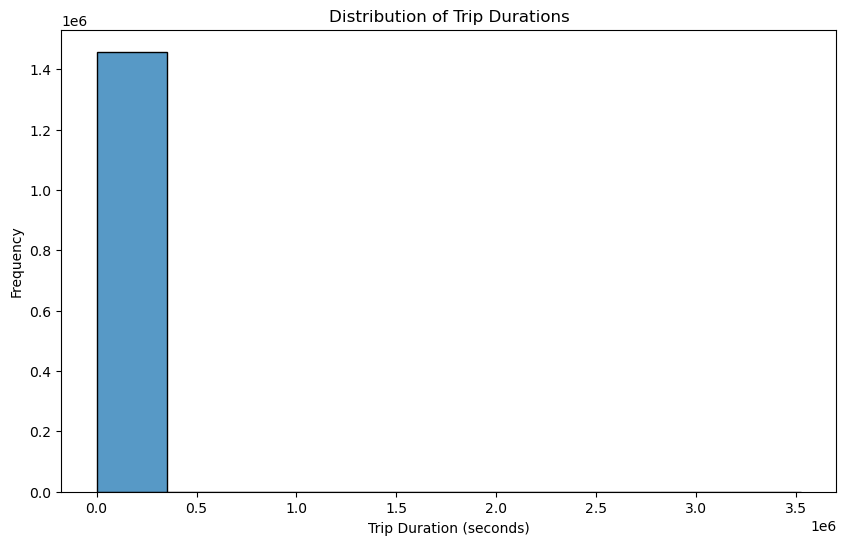

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(train['trip_duration'], bins=10, kde=False)
plt.title('Distribution of Trip Durations')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

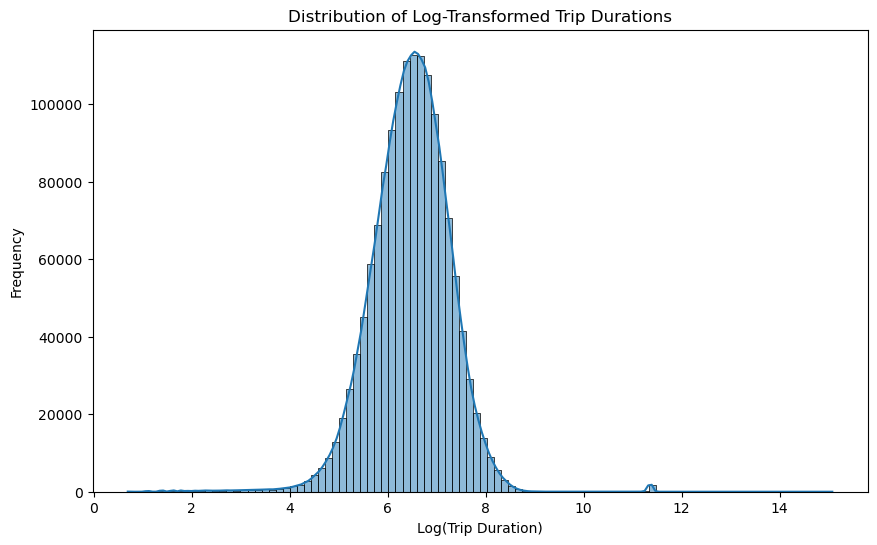

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(train['trip_duration']), bins=100, kde=True)
plt.title('Distribution of Log-Transformed Trip Durations')
plt.xlabel('Log(Trip Duration)')
plt.ylabel('Frequency')
plt.show()

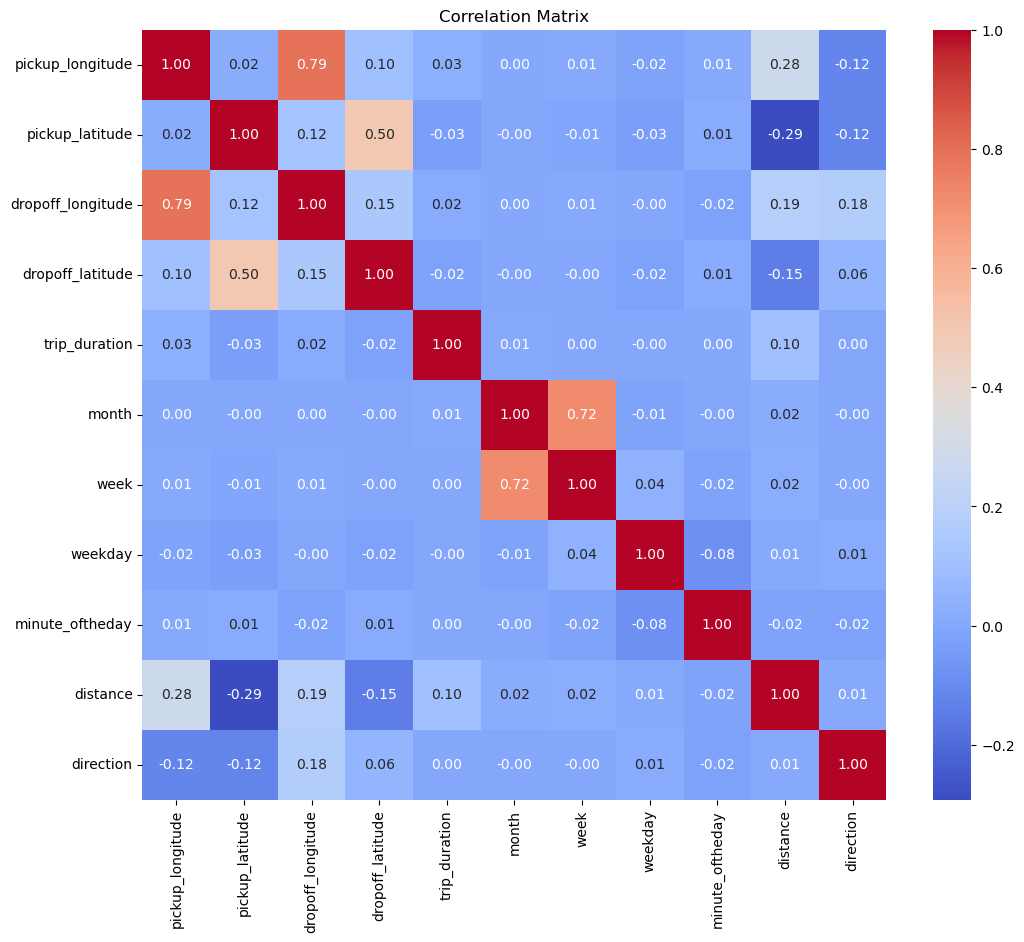

In [19]:
# Select only numeric columns for correlation calculation
numeric_train_data = train.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_train_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [21]:
# Select features
#features = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
#            'dropoff_longitude', 'dropoff_latitude', 'month', 'week',
#            'weekday', 'hour', 'minute_oftheday', 'distance', 'direction']

features = ['pickup_longitude', 'pickup_latitude',
            'dropoff_longitude', 'dropoff_latitude', 'month', 'week',
            'weekday', 'minute_oftheday', 'distance', 'direction']

# Ensure all features are present in both datasets
missing_features_train = set(features) - set(train.columns)
missing_features_test = set(features) - set(test.columns)
print("Missing features in train:", missing_features_train)
print("Missing features in test:", missing_features_test)

X = train[features]
y = np.log1p(train['trip_duration'])
X_test = test[features]

# Split data for validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Convert datasets into DMatrix
train_data = xgb.DMatrix(X_train, label=y_train)
valid_data = xgb.DMatrix(X_valid, label=y_valid)
test_data = xgb.DMatrix(X_test)

# Hyperparameter tuning with Optuna
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
    }

    # Rename the evaluation dataset to 'validation'
    pruning_callback = XGBoostPruningCallback(trial, 'validation-rmse')
    bst = xgb.train(param, train_data, evals=[(valid_data, 'validation')],
                    num_boost_round=1000,
                    early_stopping_rounds=50,
                    callbacks=[pruning_callback],
                    verbose_eval=False)

    preds = bst.predict(valid_data)
    preds = np.expm1(preds)
    y_valid_actual = np.expm1(y_valid)
    rmsle = np.sqrt(mean_squared_log_error(y_valid_actual, preds))
    return rmsle


Missing features in train: set()
Missing features in test: set()


In [23]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=3600)

[I 2024-11-30 13:53:43,054] A new study created in memory with name: no-name-5ae73811-bce8-4803-9012-343509d74925
[I 2024-11-30 13:55:01,914] Trial 0 finished with value: 0.3828534274298175 and parameters: {'max_depth': 12, 'learning_rate': 0.05248330216160598, 'subsample': 0.8265969945645573, 'colsample_bytree': 0.8689583509914177, 'min_child_weight': 19, 'lambda': 2.4655827472757676e-06, 'alpha': 0.22387538301819387}. Best is trial 0 with value: 0.3828534274298175.
[I 2024-11-30 13:56:02,968] Trial 1 finished with value: 0.3830317192533359 and parameters: {'max_depth': 13, 'learning_rate': 0.07318435943255222, 'subsample': 0.9042792678661125, 'colsample_bytree': 0.7988758193663252, 'min_child_weight': 19, 'lambda': 2.0236139026380535e-08, 'alpha': 2.826614777267746e-08}. Best is trial 0 with value: 0.3828534274298175.
[I 2024-11-30 13:57:34,861] Trial 2 finished with value: 0.3858030914042548 and parameters: {'max_depth': 9, 'learning_rate': 0.052907420372262405, 'subsample': 0.68964

In [25]:
print("Best trial:")
trial = study.best_trial
print(f"  RMSLE: {trial.value}")
print("  Best hyperparameters: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


Best trial:
  RMSLE: 0.3811014502457649
  Best hyperparameters: 
    max_depth: 12
    learning_rate: 0.024472434104054967
    subsample: 0.9541168452328763
    colsample_bytree: 0.6844653289971887
    min_child_weight: 9
    lambda: 4.245934064586346e-06
    alpha: 7.929835329446779e-06


In [27]:
# Train final model with best hyperparameters
best_params = trial.params
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'
best_params['verbosity'] = 1

# Training the final model
evals_result = {}
final_model = xgb.train(best_params, train_data,
                        evals=[(train_data, 'train'), (valid_data, 'valid')],
                        num_boost_round=2000, early_stopping_rounds=50,
                        evals_result=evals_result, verbose_eval=100)

[0]	train-rmse:0.78182	valid-rmse:0.78149
[100]	train-rmse:0.40158	valid-rmse:0.42006
[200]	train-rmse:0.36029	valid-rmse:0.39427
[300]	train-rmse:0.34262	valid-rmse:0.38847
[400]	train-rmse:0.33069	valid-rmse:0.38574
[500]	train-rmse:0.32216	valid-rmse:0.38410
[600]	train-rmse:0.31543	valid-rmse:0.38317
[700]	train-rmse:0.30893	valid-rmse:0.38245
[800]	train-rmse:0.30334	valid-rmse:0.38197
[900]	train-rmse:0.29782	valid-rmse:0.38144
[1000]	train-rmse:0.29310	valid-rmse:0.38110
[1100]	train-rmse:0.28858	valid-rmse:0.38074
[1200]	train-rmse:0.28433	valid-rmse:0.38045
[1300]	train-rmse:0.28022	valid-rmse:0.38034
[1400]	train-rmse:0.27640	valid-rmse:0.38015
[1500]	train-rmse:0.27263	valid-rmse:0.37998
[1600]	train-rmse:0.26884	valid-rmse:0.37988
[1700]	train-rmse:0.26522	valid-rmse:0.37982
[1800]	train-rmse:0.26201	valid-rmse:0.37971
[1900]	train-rmse:0.25893	valid-rmse:0.37967
[1999]	train-rmse:0.25585	valid-rmse:0.37962


In [29]:
# Predict on validation data
y_valid_pred = final_model.predict(valid_data)
y_valid_pred = np.expm1(y_valid_pred)  # Inverse of log1p
y_valid_actual = np.expm1(y_valid)     # Inverse of log1p

# Compute Metrics
mae = mean_absolute_error(y_valid_actual, y_valid_pred)
mse = mean_squared_error(y_valid_actual, y_valid_pred)
rmse = np.sqrt(mse)
rmsle = np.sqrt(mean_squared_log_error(y_valid_actual, y_valid_pred))

print("Validation MAE:", mae)
print("Validation MSE:", mse)
print("Validation RMSE:", rmse)
print("Validation RMSLE:", rmsle)


Validation MAE: 278.472717371672
Validation MSE: 10170867.613550143
Validation RMSE: 3189.179771281347
Validation RMSLE: 0.3796151016998397


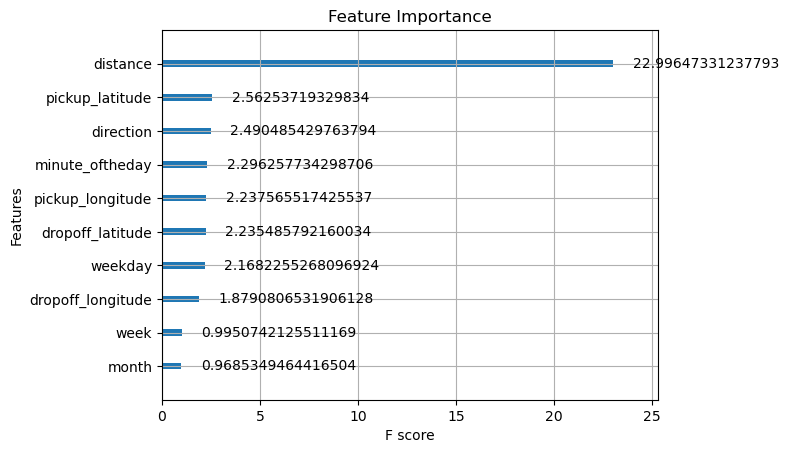

In [31]:
# Plotting Feature Importance
xgb.plot_importance(final_model, max_num_features=20, importance_type='gain')
plt.title('Feature Importance')
plt.show()


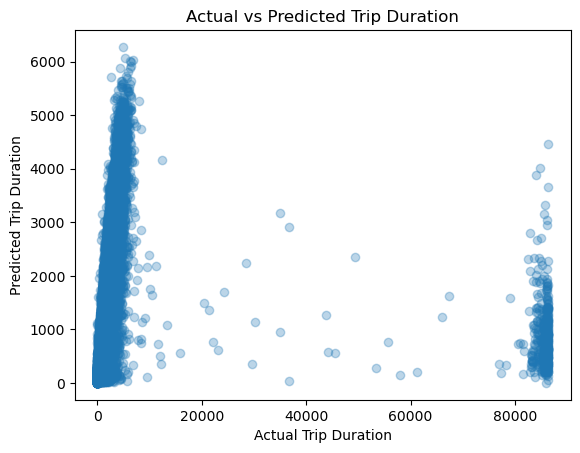

In [33]:
# Plotting Actual vs Predicted
plt.scatter(y_valid_actual, y_valid_pred, alpha=0.3)
plt.xlabel('Actual Trip Duration')
plt.ylabel('Predicted Trip Duration')
plt.title('Actual vs Predicted Trip Duration')
plt.show()

In [35]:
# Plotting Learning Curve
results = evals_result
epochs = len(results['train']['rmse'])
x_axis = range(0, epochs)

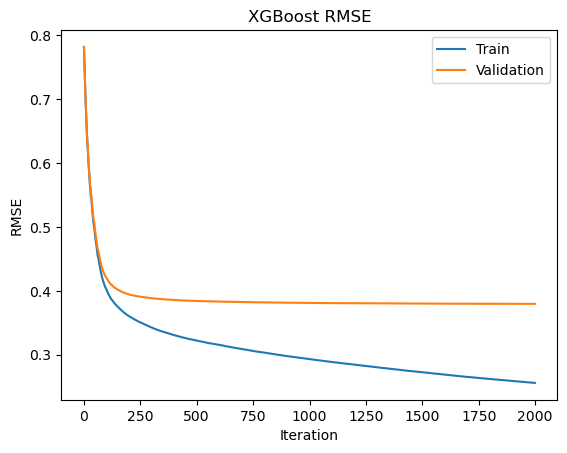

In [37]:
# Plot RMSE
fig, ax = plt.subplots()
ax.plot(x_axis, results['train']['rmse'], label='Train')
ax.plot(x_axis, results['valid']['rmse'], label='Validation')
ax.legend()
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('XGBoost RMSE')
plt.show()

In [39]:
# Predict on test data
y_pred = final_model.predict(test_data)
y_pred = np.expm1(y_pred)  # Inverse of log1p

In [40]:
# Prepare submission
submission = pd.DataFrame({'id': test['id'], 'trip_duration': y_pred})
submission.to_csv('alternatif3b.submission.csv', index=False)

In [43]:
import shap
# Initialize the JavaScript visualization code
shap.initjs()

# Create TreeExplainer object
explainer = shap.TreeExplainer(final_model)

# Sample the validation set for SHAP analysis
X_valid_sample = X_valid.sample(n=1000, random_state=42)

# Compute SHAP values for the sampled validation set
shap_values = explainer.shap_values(X_valid_sample)


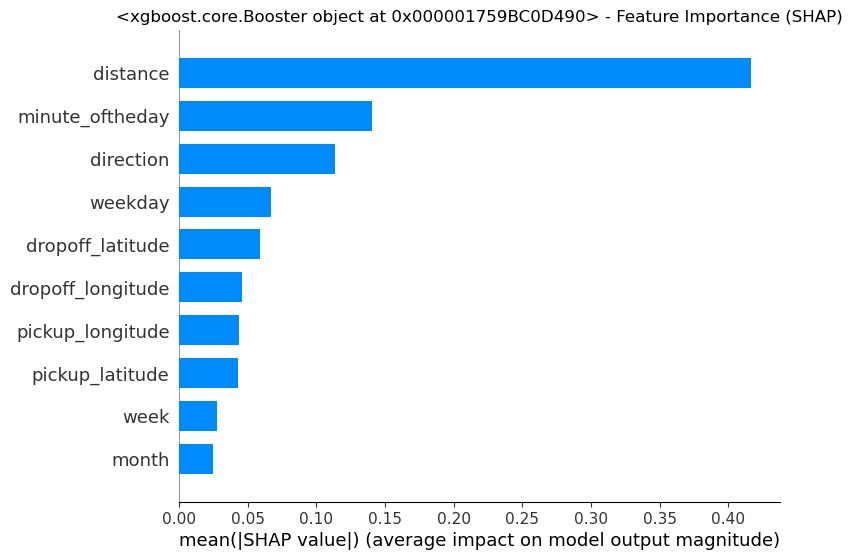

In [44]:
shap.summary_plot(shap_values, X_valid_sample, plot_type='bar', show=False)
plt.title(f'{final_model} - Feature Importance (SHAP)')
plt.show()

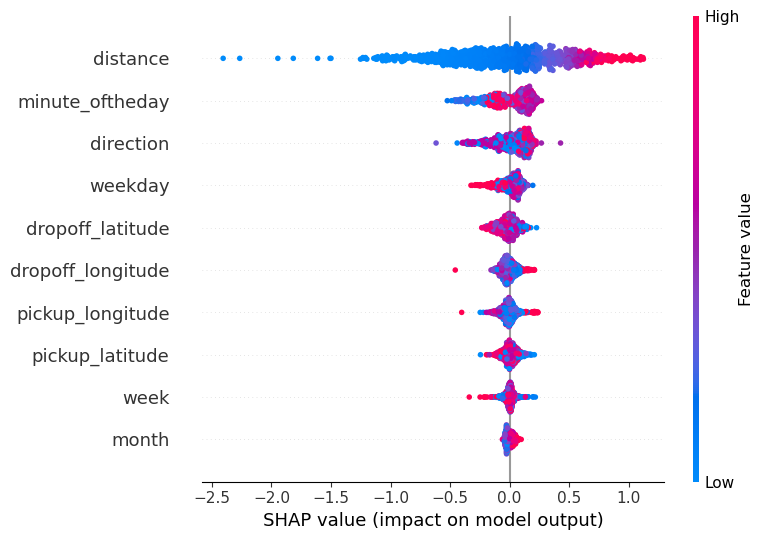

<Figure size 640x480 with 0 Axes>

In [45]:
# SHAP summary plot
shap.summary_plot(shap_values, X_valid_sample)
plt.savefig('shap_summary_plot.png')

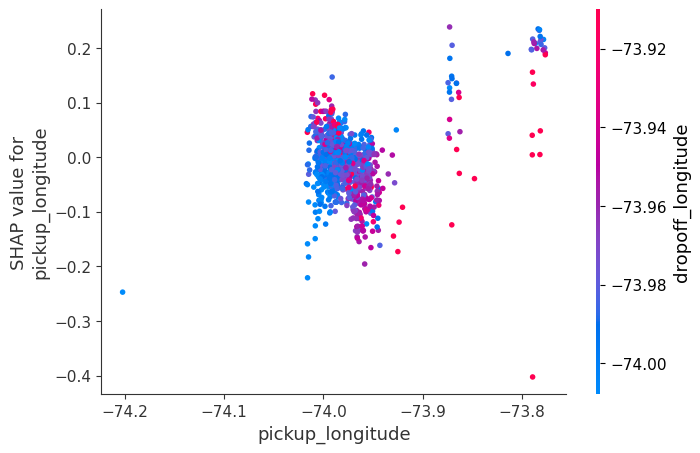

<Figure size 640x480 with 0 Axes>

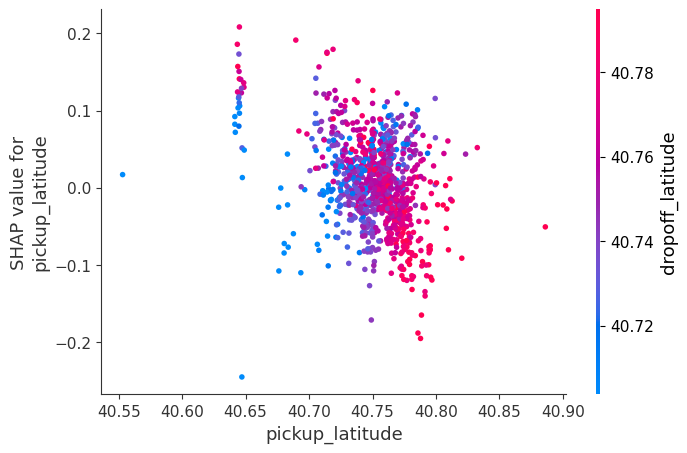

<Figure size 640x480 with 0 Axes>

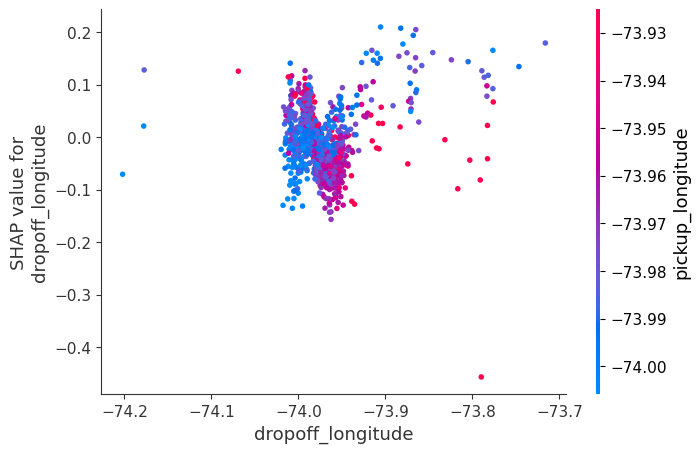

<Figure size 640x480 with 0 Axes>

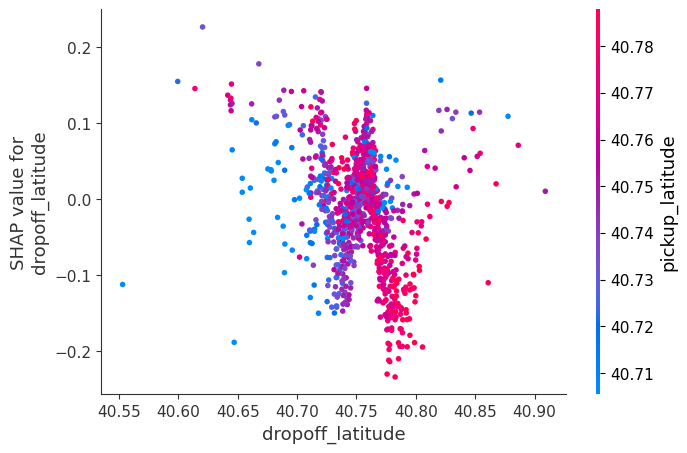

<Figure size 640x480 with 0 Axes>

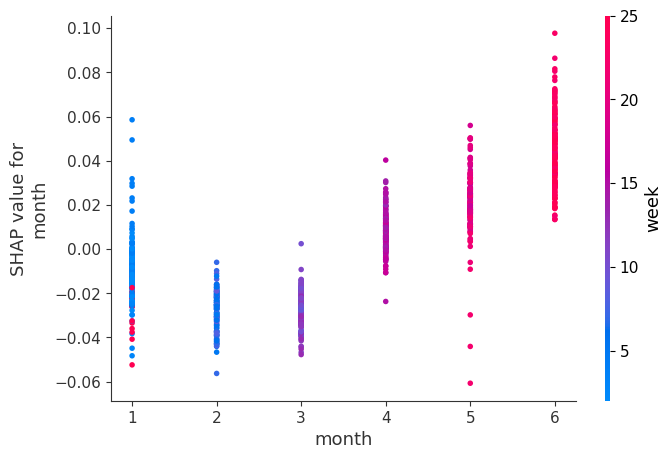

<Figure size 640x480 with 0 Axes>

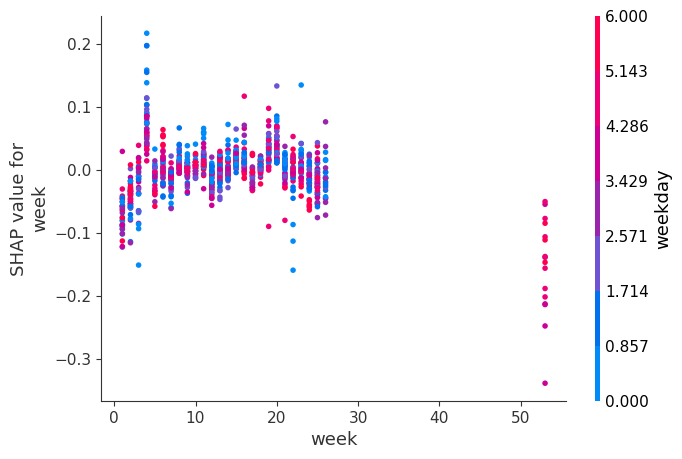

<Figure size 640x480 with 0 Axes>

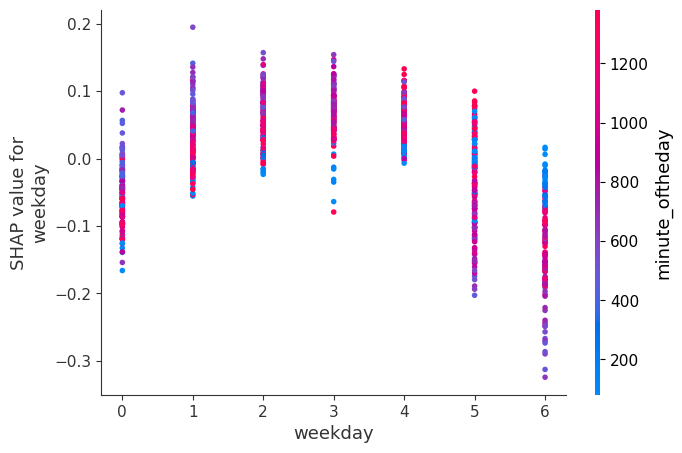

<Figure size 640x480 with 0 Axes>

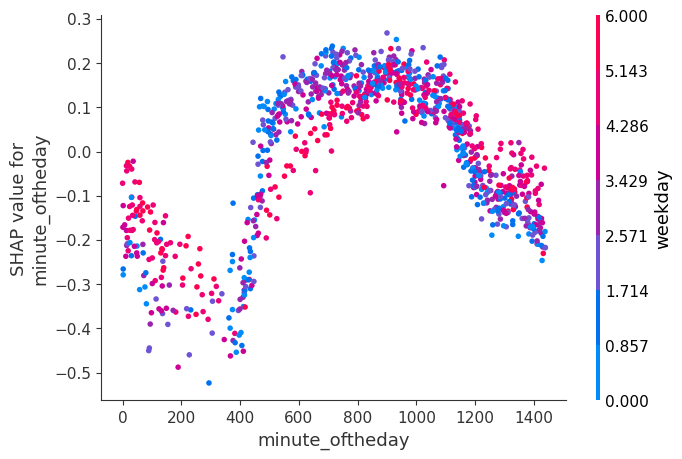

<Figure size 640x480 with 0 Axes>

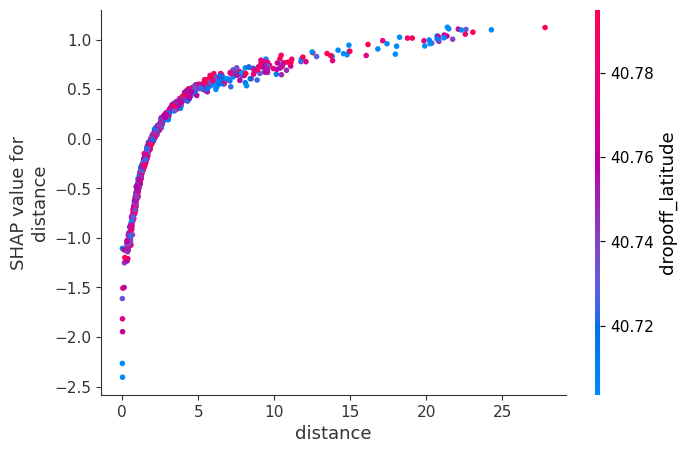

<Figure size 640x480 with 0 Axes>

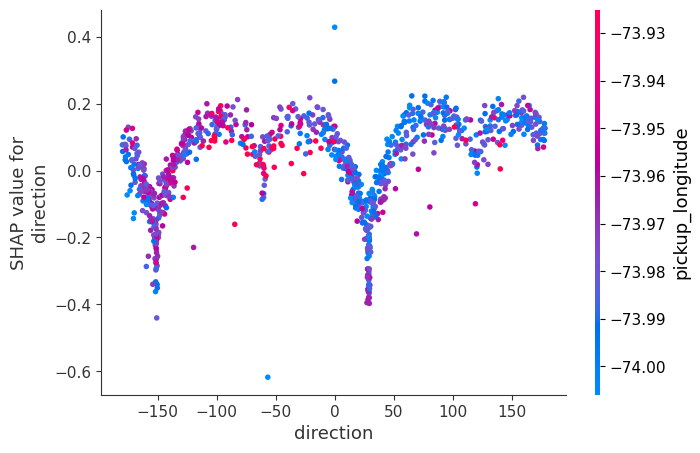

<Figure size 640x480 with 0 Axes>

In [53]:
# SHAP dependence plots for top features
top_features = ['pickup_longitude', 'pickup_latitude',
            'dropoff_longitude', 'dropoff_latitude', 'month', 'week',
            'weekday', 'minute_oftheday', 'distance', 'direction']  # Adjust based on your SHAP summary plot
for feature in top_features:
    shap.dependence_plot(feature, shap_values, X_valid_sample)
    #plt.savefig(f'shap_dependence_plot_{feature}.png')

In [55]:
# SHAP force plot for a single prediction
index = 0  # Change to the index of the instance you're interested in
shap.force_plot(explainer.expected_value, shap_values[index], X_valid_sample.iloc[index])


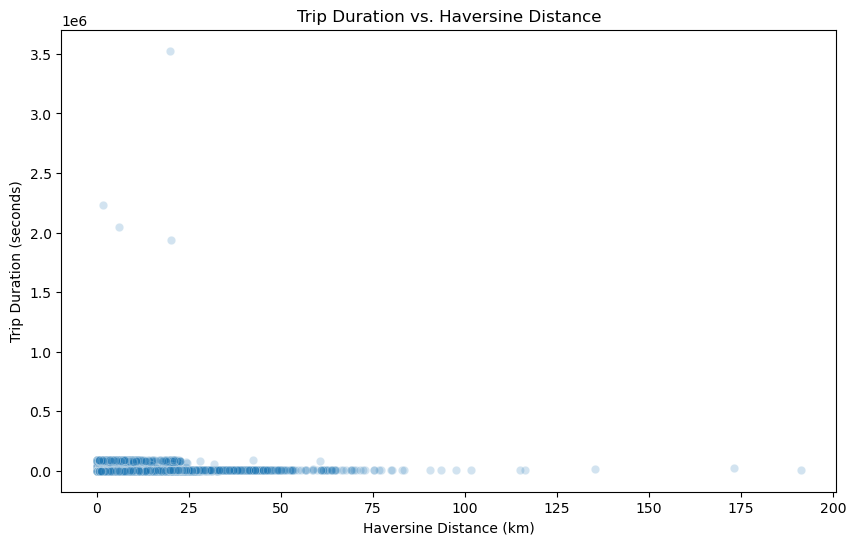

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='trip_duration', data=train, alpha=0.2)
plt.title('Trip Duration vs. Haversine Distance')
plt.xlabel('Haversine Distance (km)')
plt.ylabel('Trip Duration (seconds)')
plt.show()

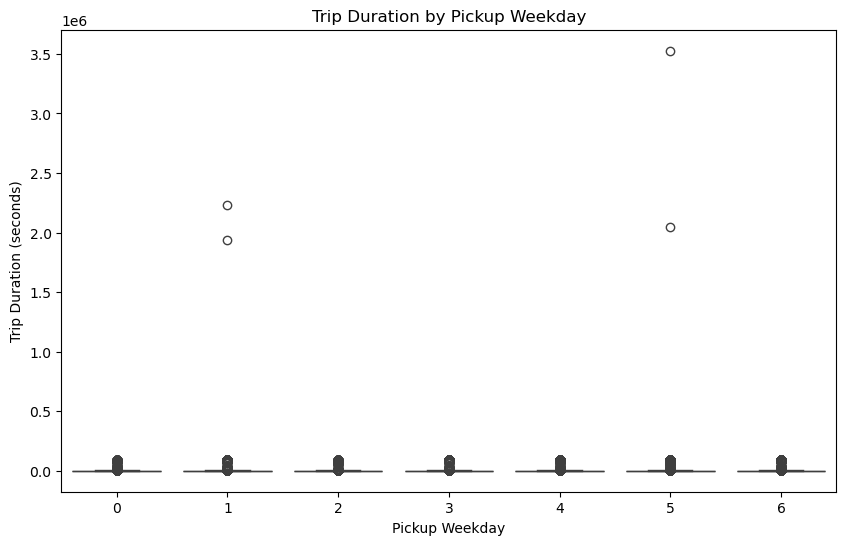

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='weekday', y='trip_duration', data=train)
plt.title('Trip Duration by Pickup Weekday')
plt.xlabel('Pickup Weekday')
plt.ylabel('Trip Duration (seconds)')
plt.show()

In [61]:
# Stacked force plot for the first 101 values (interactive) (Explainer)
#shap.plots.force(shap_values[0:100])
shap.plots.force(explainer.expected_value, shap_values)